## E-Commerce Consumer Behavior Analysis
#### Author : Bhavya Jain

##### Goal - 
1. Convert raw transaction data into meaningful business insights.
2. Identify customer behaviour patterns that can support marketing and sales decisions, which products and countries contribute the most, and how revenue changes over time.

#### 1. Import Libraries

In [109]:
# pandas -> data manipulation
# numpy -> numerical operations
# matplotlib & seaborn -> visualization

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_style("whitegrid")

#### 2. Load Dataset

In [111]:
# We load the raw transactional log file. Each row = one product line inside an order (NOT a full order). 
# Obs 1: Dataset is Billing Log & Not Order summary

In [112]:
# Load dataset
df = pd.read_csv('../data/data.csv')
print("Dataset loaded successfully!")

print("Dataset initial shape:", df.shape)
print(df.head(10))

Dataset loaded successfully!
Dataset initial shape: (541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
5    536365     22752         SET 7 BABUSHKA NESTING BOXES         2   
6    536365     21730    GLASS STAR FROSTED T-LIGHT HOLDER         6   
7    536366     22633               HAND WARMER UNION JACK         6   
8    536366     22632            HAND WARMER RED POLKA DOT         6   
9    536367     84879        ASSORTED COLOUR BIRD ORNAMENT        32   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  12-01-2010 08:26       2.55     17850.0  United Kingdom  
1  12-01-2010 08:26  

#### 3. Understand Columns

In [113]:
#  InvoiceNo -> unique bill id
#  StockCode -> product id
#  Description -> product name
#  Quantity -> number of items purchased
#  InvoiceDate -> time of purchase
#  UnitPrice -> price per item
#  CustomerID -> user id
#  Country -> location of customer

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [115]:
print(df.describe())

            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000


In [116]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


#### 4. Data Cleaning 

In [117]:
# Real-world billing logs contain noise:
# 1. cancelled orders (negative quantity)
# 2. missing customers (guest / anonymous checkout)
# 3. invalid prices

In [118]:
# Remove missing customers (cannot track behavior)
df = df.dropna(subset=['CustomerID'])

In [119]:
# Remove cancelled or returned items
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Drop duplicate rows if any
df.drop_duplicates(inplace=True)

In [120]:
# # Verify the changes
print("Shape after cleaning:", df.shape)
df.info()

Shape after cleaning: (392692, 8)
<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  object 
 1   StockCode    392692 non-null  object 
 2   Description  392692 non-null  object 
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  object 
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  float64
 7   Country      392692 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.0+ MB


#### 5. Feature Engineering

In [121]:
# Right now your InvoiceDate is text, not time.
# Convert date to datetime for time analysis.
# We need time because behavior depends on when last purchase happened

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True, errors='coerce')
# errors='coerce' if any weird corrupted date exists, convert it to NaT instead of crashing

# Because corrupted timestamps become missing values.
df = df.dropna(subset=['InvoiceDate'])


In [122]:
# Extract time components
# Now that date is fixed, we can understand: 
# WHEN customers shop (seasonality & habits)

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

# Why this matters:
# Businesses run differently on weekends, evenings, festive months etc
# Helps in demand forecasting & staffing decisions

print(df[['InvoiceDate','Year','Month','Day','Hour']].head())

          InvoiceDate  Year  Month      Day  Hour
0 2010-01-12 08:26:00  2010      1  Tuesday     8
1 2010-01-12 08:26:00  2010      1  Tuesday     8
2 2010-01-12 08:26:00  2010      1  Tuesday     8
3 2010-01-12 08:26:00  2010      1  Tuesday     8
4 2010-01-12 08:26:00  2010      1  Tuesday     8


##### 6. Revenue Feature

In [123]:
# Revenue is not given directly
# We calculate transaction value: Revenue = Quantity × UnitPrice

df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Why this matters:
# Revenue is the most important business KPI
# Needed for customer value & segmentation

print(df[['Quantity','UnitPrice','Revenue']].head())

   Quantity  UnitPrice  Revenue
0         6       2.55    15.30
1         6       3.39    20.34
2         8       2.75    22.00
3         6       3.39    20.34
4         6       3.39    20.34


##### 7. Monthly Sales Trend (Business Performance Analysis)

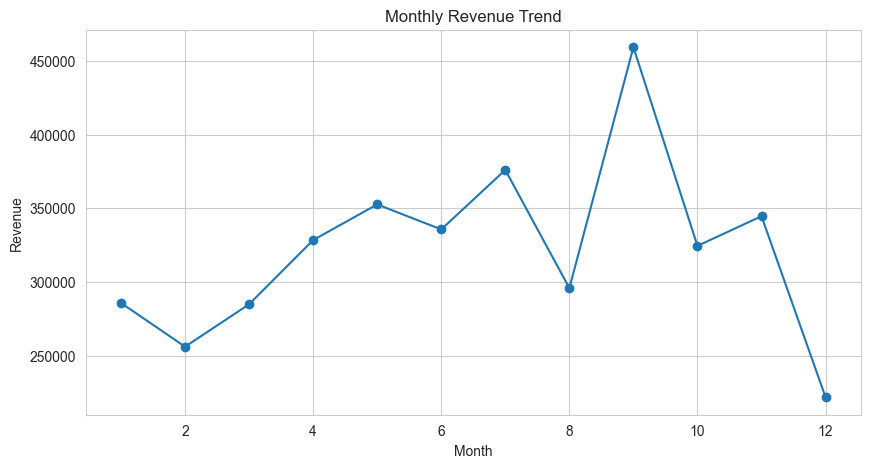

In [124]:
# Goal: When does the business earn most money? 
monthly_sales = df.groupby('Month')['Revenue'].sum() 
plt.figure(figsize=(10,5)) 
monthly_sales.plot(kind='line', marker='o') 
plt.title("Monthly Revenue Trend") 
plt.ylabel("Revenue") 
plt.xlabel("Month") 
plt.show() 
# Insight: Helps business plan inventory for peak season

##### 8. Top Products by Revenue

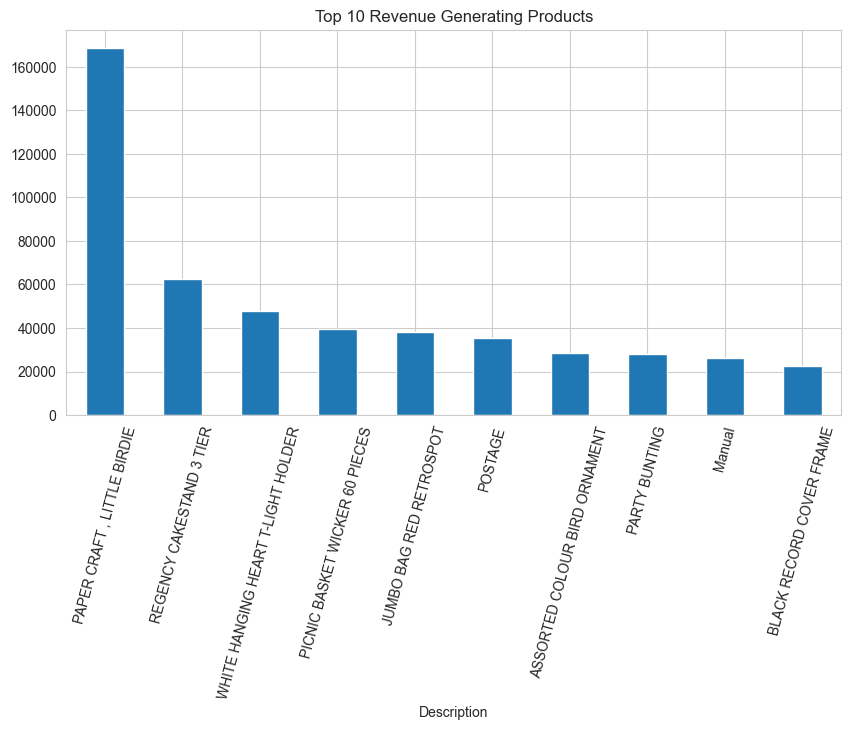

In [125]:
top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title("Top 10 Revenue Generating Products")
plt.xticks(rotation=75)
plt.show()

# Outcome:
# Identify best selling items
# Useful for promotions & recommendations


##### 9. Country Revenue Analysis

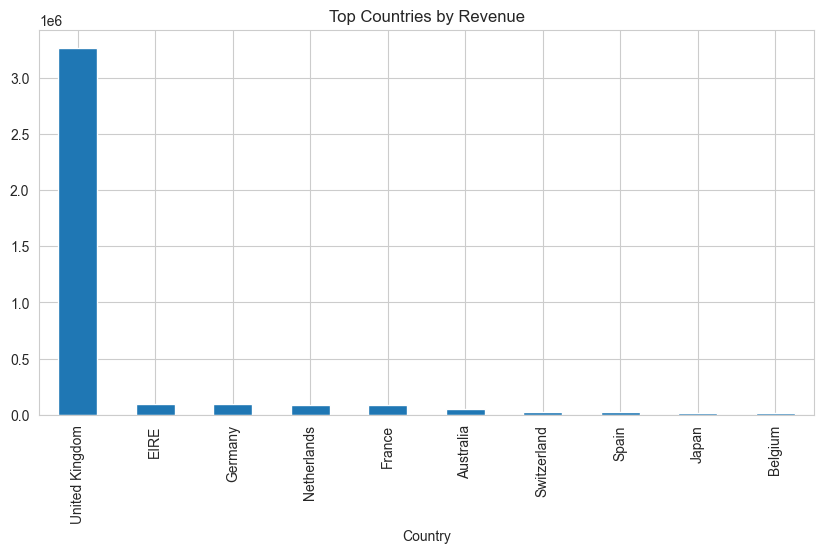

In [126]:
country_sales = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
country_sales.plot(kind='bar')
plt.title("Top Countries by Revenue")
plt.show()

# Outcome:
# Find strongest markets
# Helps geo-target marketing budget


##### 10. Customer Level Aggregation (Required before Segmentation)

In [127]:
# Customer Level Metrics
# Convert transaction data → customer behaviour data

customer_df = df.groupby('CustomerID').agg({
    'InvoiceNo':'nunique',   # purchase frequency
    'Quantity':'sum',        # purchase volume
    'Revenue':'sum'          # total spend
}).rename(columns={'InvoiceNo':'TotalOrders'})

print(customer_df.head())


            TotalOrders  Quantity  Revenue
CustomerID                                
12347.0               5      1467  2540.29
12348.0               1       269   367.00
12350.0               1       197   334.40
12352.0               3       156  1296.38
12355.0               1       240   459.40


##### 11. RFM Segmentation

In [128]:
# Recency reference date (one day after last purchase in dataset)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']

print(rfm.head())
# This helps identify VIP customers vs one-time buyers

            Recency  Frequency  Monetary
CustomerID                              
12347.0          96          5   2540.29
12348.0         221          1    367.00
12350.0         312          1    334.40
12352.0         275          3   1296.38
12355.0          97          1    459.40


In [129]:
# Right now your rfm table only has numbers
# we care about: 
# Who are my loyal customers? Who will leave? Who should I target?
# So we will convert analytics → strategy

##### 12. Score Customers (RFM Scoring)

In [130]:
# We rank customers from 1 to 4 based on how good they are.

# Low recency (recent purchase) = GOOD
# High frequency = GOOD
# High money spent = GOOD

In [131]:
# We divide customers into quartiles (4 groups)
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

# Combine scores into single code
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

print(rfm.head())


            Recency  Frequency  Monetary R_score F_score M_score RFM_Score
CustomerID                                                                
12347.0          96          5   2540.29       3       4       4       344
12348.0         221          1    367.00       1       1       2       112
12350.0         312          1    334.40       1       1       2       112
12352.0         275          3   1296.38       1       3       4       134
12355.0          97          1    459.40       3       1       2       312


In [132]:
# What does this mean:
# converted raw behavioral metrics into a standardized scoring system 
# so customers could be compared fairly.


##### 13. Customer Segmentation (Business Labels)

In [133]:
def segment_customer(row):
    
    if row['R_score']==4 and row['F_score']>=3:
        return 'Champions'
    
    elif row['R_score']>=3 and row['F_score']>=2:
        return 'Loyal Customers'
    
    elif row['R_score']==4 and row['F_score']==1:
        return 'New Customers'
    
    elif row['R_score']==2 and row['F_score']>=2:
        return 'Potential Loyalists'
    
    elif row['R_score']==1 and row['F_score']>=2:
        return 'At Risk'
    
    else:
        return 'Lost Customers'


rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print(rfm['Segment'].value_counts())

# Translated statistical scores into business personas 
# marketing teams can take direct actions.

Segment
Loyal Customers        686
Lost Customers         635
Champions              563
Potential Loyalists    540
At Risk                458
New Customers          115
Name: count, dtype: int64


##### 14. Visualize Customer Distribution

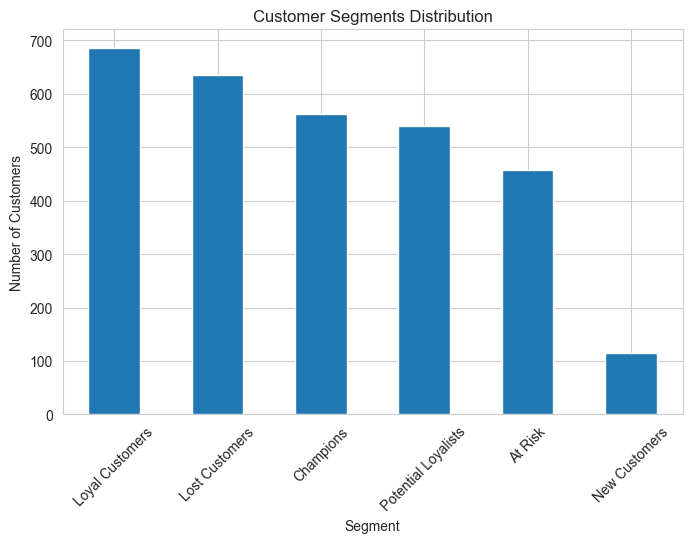

In [134]:
plt.figure(figsize=(8,5))
rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

##### 15. Business Insight Table

In [135]:
# Segment Revenue Contribution
# Which type of customer actually earns money?

segment_revenue = rfm.merge(customer_df, on='CustomerID')

segment_summary = segment_revenue.groupby('Segment').agg({
    'Revenue':'sum',
    'TotalOrders':'mean'
}).sort_values(by='Revenue', ascending=False)

print(segment_summary)


                        Revenue  TotalOrders
Segment                                     
Champions            1617536.50     5.872114
Loyal Customers      1239114.02     2.913994
Potential Loyalists   470433.66     2.233333
Lost Customers        246518.51     1.000000
At Risk               239591.52     1.528384
New Customers          52268.87     1.000000


In [136]:
# TILL NOW PROJECT IS
# Descriptive + Diagnostic Analytics (what happened & why)

In [137]:
# Predictive Analytics → 
# Which customer is likely to churn (not come back)?

# Business meaning: 
# Company can send coupons only to customers who are about to leave 
# instead of wasting money on everyone.

##### 16. Create Target Variable (Churn)

In [138]:
# If customer has not purchased for 90+ days → considered churned

rfm['Churn'] = rfm['Recency'].apply(lambda x: 1 if x > 90 else 0)

# 1 = Will leave
# 0 = Active customer

print(rfm['Churn'].value_counts())

# converted inactivity into a machine learning target variable.

Churn
1    1883
0    1114
Name: count, dtype: int64


##### 17. Prepare Features for ML

In [139]:
ml_df = rfm[['Recency','Frequency','Monetary','Churn']]

X = ml_df[['Recency','Frequency','Monetary']]
y = ml_df['Churn']


##### 18. Train Test Spliting 

In [140]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


##### 19. Train Model (Logistic Regression)

In [141]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


##### 19. Predictions

In [142]:
y_pred = model.predict(X_test)

##### 20. Evaluate Model

In [143]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

# However, I didn’t rely only on accuracy 
# because churn datasets are usually imbalanced. 
# I also checked precision and recall using the classification report 
# to ensure the model correctly identifies churn-risk customers, 
# which matters more than overall accuracy in business scenarios.

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       207
           1       1.00      1.00      1.00       393

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

[[207   0]
 [  0 393]]
